# NLP Spam Sentiment Classification

## Table of Contents

1. [Data Loading and Initial Inspection](#1-data-loading-and-initial-inspection)
2. [Summary Statistics](#2-summary-statistics)
3. [Data Cleaning and Preprocessing](#3-data-cleaning-and-preprocessing)
   - [Dropping Unnecessary Columns](#dropping-unnecessary-columns)
   - [Renaming Columns for Clarity](#renaming-columns-for-clarity)
   - [Checking for Missing Values](#checking-for-missing-values)
   - [Helper Functions for Exploratory Data Analysis](#helper-functions-for-exploratory-data-analysis)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Model Preprocessing](#5-model-preprocessing)
6. [Models](#6-models)
7. [Model Evaluation](#7-model-evaluation)
   - [Confusion Matrices](#confusion-matrices)
   - [Precision vs. Recall Tradeoff](#precision-vs-recall-tradeoff)
   - [Misclassified Examples](#misclassified-examples)
8. [Conclusion](#8-conclusion)

In [346]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

nltk.download('stopwords')
nltk.download('wordnet')

path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
print("Dataset downloaded to:", path)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Dataset downloaded to: /kaggle/input/sms-spam-collection-dataset


# 1. Data Loading and Initial Inspection

In [347]:
df = pd.read_csv(f"{path}/spam.csv", encoding='latin1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [348]:
df.tail(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


# 2. Summary Statistics

In [349]:
df.info()
print(df.shape)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


# 3. Data Cleaning and Preprocessing

## Dropping Unnecessary Columns



In [350]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)


### Renaming Columns for Clarity

In [351]:
df = df.rename(columns={'v1':'label', 'v2':'text'})
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Checking for Missing Values



In [352]:
df.isnull().sum()

,0
label,0
text,0


## Helper Functions for Exploratory Data Analysis

In [353]:
def check_class_balance(df, target_column):
    counts = df[target_column].value_counts()
    percentages = df[target_column].value_counts(normalize=True) * 100

    print("Counts:\n", counts)
    print("\nPercentages:\n", percentages)

    spam_pct = (df[target_column] == "spam").mean() * 100
    if 12 <= spam_pct <= 13:
        print("\nNote: Dataset is imbalanced (~12-13% spam)")


def check_text_length(df, text_column, label_column):
    df["text_length"] = df[text_column].astype(str).apply(len)
    print(df.groupby(label_column)["text_length"].mean())


def show_top_words(df, text_col, label_col, top_n=10, stopwords=None):
    results = {}
    for category in df[label_col].unique():
        all_text = " ".join(df[df[label_col] == category][text_col].astype(str))
        words = [word.lower() for word in all_text.split() if word.lower().isalpha()]
        if stopwords:
            words = [word for word in words if word not in stopwords]
        common = Counter(words).most_common(top_n)
        print(f"\nTop {top_n} words in {category}:", common)
        results[category] = common
    return results

In [354]:
custom_stopwords = set(list(STOPWORDS) + ['u', 'ur', '2', '4', 'im', 'dont', 'do', 'will', 'go', 'got', 'like', 'come', 'know', 'get'])
check_class_balance(df, "label")
check_text_length(df, "text", "label")

show_top_words(df, "text", "label", top_n=10, stopwords=custom_stopwords)

Counts:
 label
ham     4825
spam     747
Name: count, dtype: int64

Percentages:
 label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64
label
ham      71.023627
spam    138.866131
Name: text_length, dtype: float64

Top 10 words in ham: [('call', 215), ('good', 187), ('going', 157), ('ok', 156), ('now', 154), ('want', 153), ('time', 153), ('love', 149), ('need', 147), ('still', 144)]

Top 10 words in spam: [('call', 342), ('free', 180), ('txt', 136), ('text', 112), ('mobile', 109), ('claim', 106), ('reply', 101), ('now', 93), ('stop', 89), ('new', 69)]


{'ham': [('call', 215),
  ('good', 187),
  ('going', 157),
  ('ok', 156),
  ('now', 154),
  ('want', 153),
  ('time', 153),
  ('love', 149),
  ('need', 147),
  ('still', 144)],
 'spam': [('call', 342),
  ('free', 180),
  ('txt', 136),
  ('text', 112),
  ('mobile', 109),
  ('claim', 106),
  ('reply', 101),
  ('now', 93),
  ('stop', 89),
  ('new', 69)]}

In [355]:
word_distributions = show_top_words(df, 'text', 'label', top_n=10, stopwords=custom_stopwords)

ham_top_words = word_distributions.get('ham', [])
spam_top_words = word_distributions.get('spam', [])

ham_words = " ".join(df[df['label'] == 'ham']['text'].astype(str))
spam_words = " ".join(df[df['label'] == 'spam']['text'].astype(str))

ham_df = pd.DataFrame(ham_top_words, columns=['word', 'count'])
spam_df = pd.DataFrame(spam_top_words, columns=['word', 'count'])

ham_wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(ham_words)
spam_wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(spam_words)


Top 10 words in ham: [('call', 215), ('good', 187), ('going', 157), ('ok', 156), ('now', 154), ('want', 153), ('time', 153), ('love', 149), ('need', 147), ('still', 144)]

Top 10 words in spam: [('call', 342), ('free', 180), ('txt', 136), ('text', 112), ('mobile', 109), ('claim', 106), ('reply', 101), ('now', 93), ('stop', 89), ('new', 69)]


# 4. Exploratory Data Analysis

In [356]:
sns.set_style('whitegrid')
palette = ['#4C72B0', '#DD8452']
model_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#E377C2']
metric_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

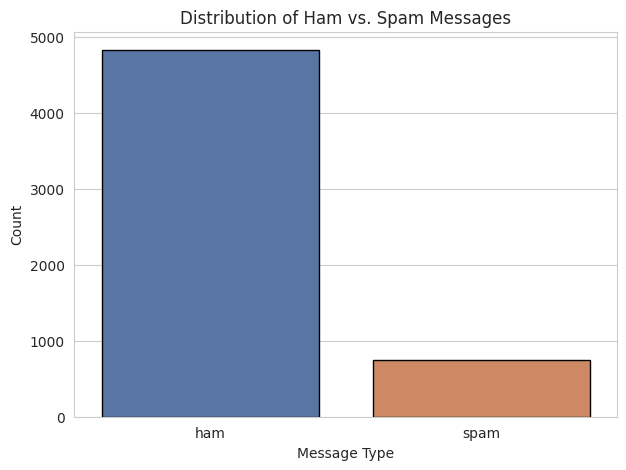

In [357]:
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, hue='label', palette=palette, legend=False, edgecolor='black')
plt.title('Distribution of Ham vs. Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

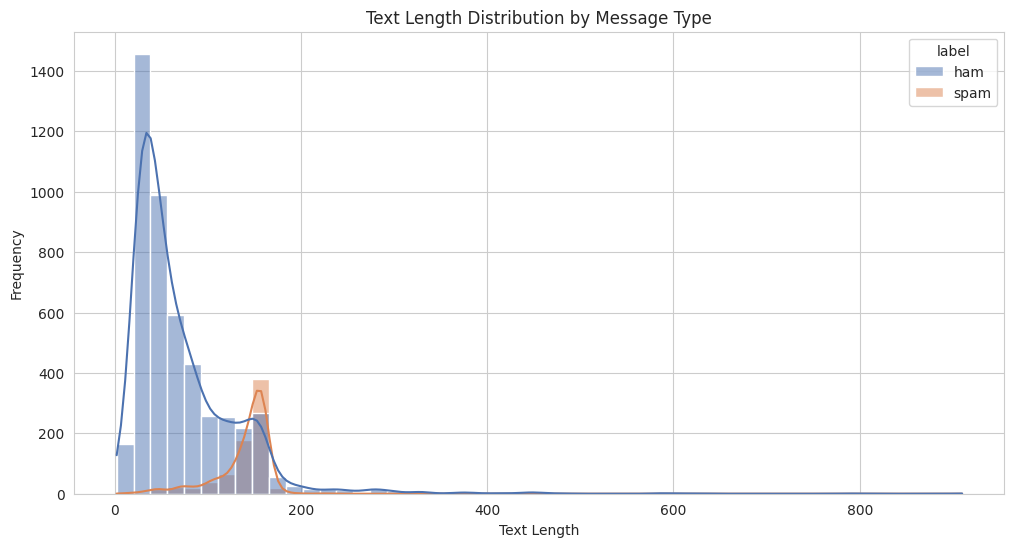

In [358]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='text_length', hue='label', bins=50, palette=palette, kde=True)
plt.title('Text Length Distribution by Message Type')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

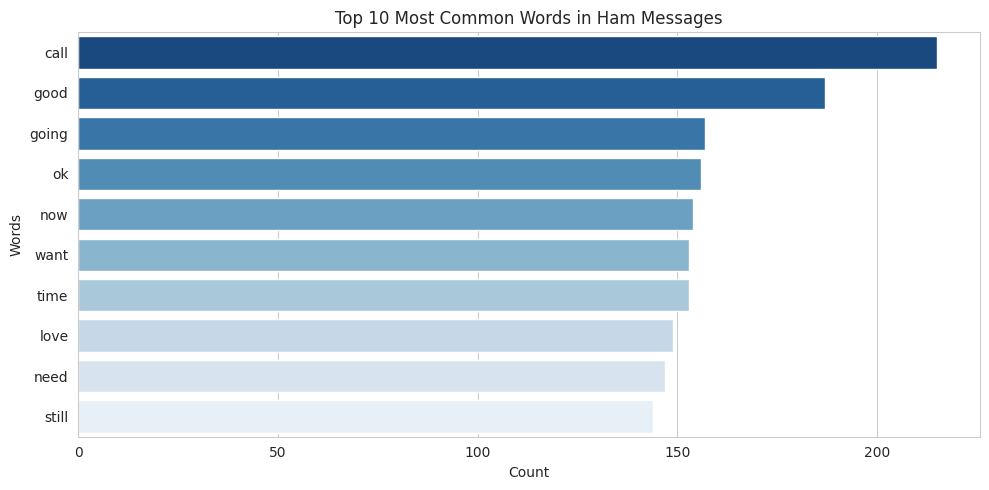

In [359]:

plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='word', data=ham_df, palette='Blues_r', hue='word', legend=False)
plt.title('Top 10 Most Common Words in Ham Messages')
plt.xlabel('Count')
plt.ylabel('Words')
plt.tight_layout()
plt.show()



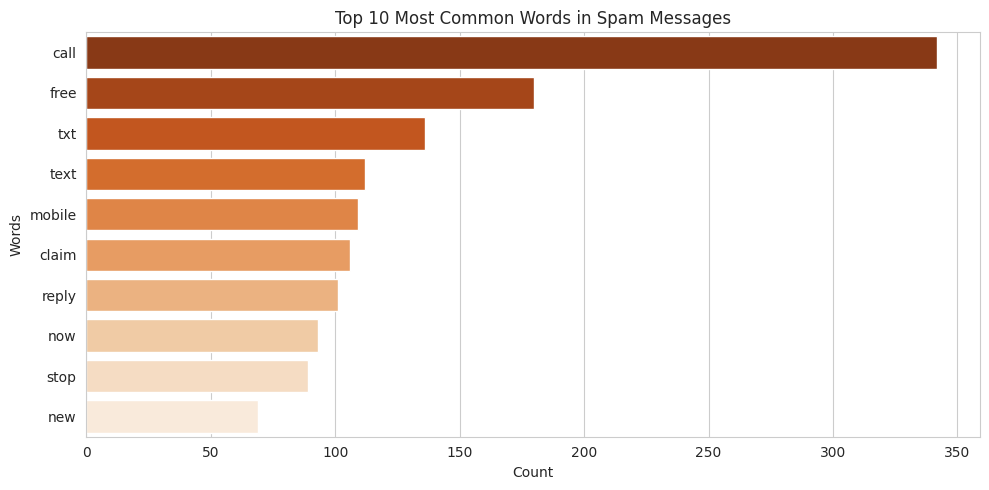

In [360]:
plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='word', data=spam_df, palette='Oranges_r', hue='word', legend=False)
plt.title('Top 10 Most Common Words in Spam Messages')
plt.xlabel('Count')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

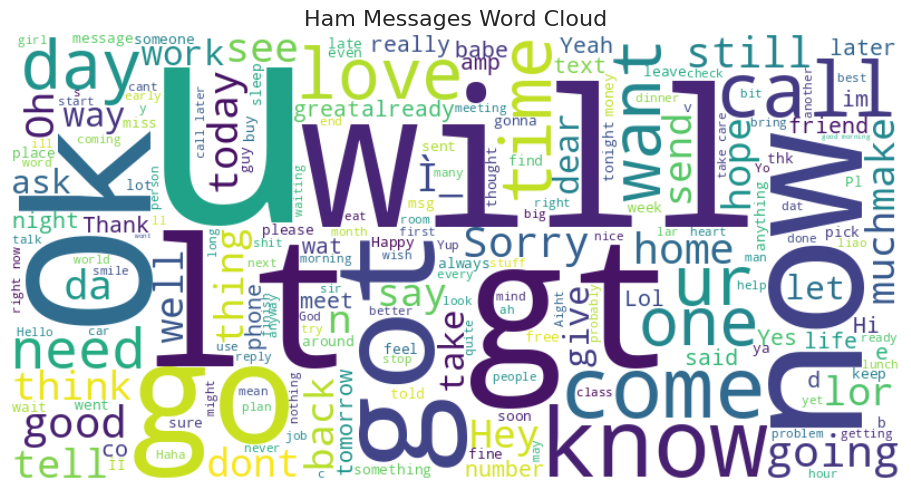

In [361]:

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.title('Ham Messages Word Cloud', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

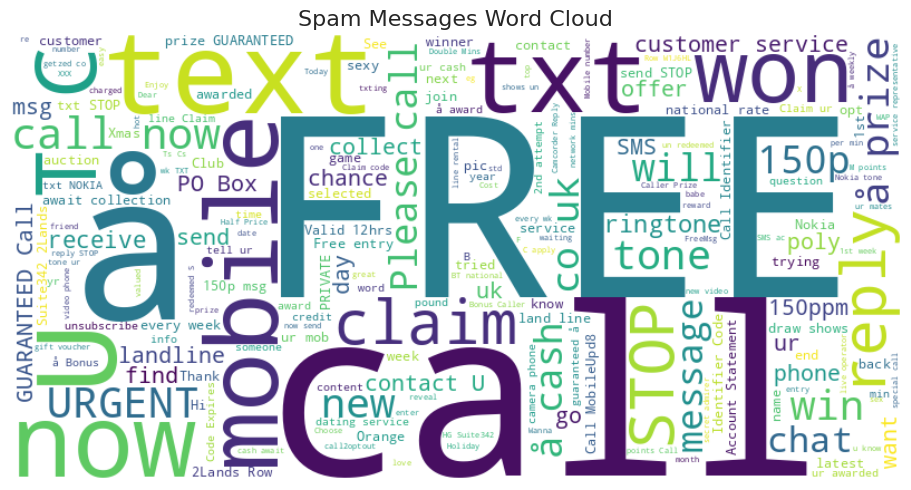

In [362]:
plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.title('Spam Messages Word Cloud', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# 5. Model Preprocessing

In [363]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    cleaned_words = [
        lemmatizer.lemmatize(word) for word in words if word not in stop_words
    ]

    return ' '.join(cleaned_words)



df['clean_text'] = df['text'].apply(preprocess_text)
df['clean_text'].head()

,clean_text
0,go jurong point crazy available bugis n great ...
1,ok lar joking wif u oni
2,free entry wkly comp win fa cup final tkts st ...
3,u dun say early hor u c already say
4,nah dont think go usf life around though


In [ ]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Models

In [365]:
VECTORIZERS = {
    'CountVectorizer': CountVectorizer,
    'TfidfVectorizer': TfidfVectorizer,
}

DEFAULT_MODELS = {
    'Dummy Classifier': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}


def evaluate_model(model, name, X_train, X_test, y_train, y_test):
    results = []
    for vec_name, vectorizer_cls in VECTORIZERS.items():
        pipeline = build_pipeline(model, vectorizer_cls)

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='macro', zero_division=0
        )

        results.append({
            'Model': name,
            'Vectorizer': vec_name,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1 Score': round(f1, 4),
        })
    return pd.DataFrame(results)


def evaluate_models(X_train, X_test, y_train, y_test, models=None):
    models = DEFAULT_MODELS if models is None else models
    return pd.concat(
        [
            evaluate_model(model, name, X_train, X_test, y_train, y_test)
            for name, model in models.items()
        ],
        ignore_index=True,
    )

def build_pipeline(model, vectorizer_cls):
    """Fresh pipeline with its own estimator copy (avoids shared fitted state)."""
    return Pipeline([
        ('vectorizer', vectorizer_cls()),
        ('classifier', clone(model)),
    ])

In [366]:
results_df = evaluate_models(X_train, X_test, y_train, y_test)
display(results_df)

,Model,Vectorizer,Accuracy,Precision,Recall,F1 Score
0,Dummy Classifier,CountVectorizer,0.8664,0.4332,0.5000,0.4642
1,Dummy Classifier,TfidfVectorizer,0.8664,0.4332,0.5000,0.4642
2,Logistic Regression,CountVectorizer,0.9839,0.9909,0.9396,0.9632
3,Logistic Regression,TfidfVectorizer,0.9641,0.9761,0.8686,0.9129
4,Multinomial Naive Bayes,CountVectorizer,0.9803,0.9731,0.9404,0.9559
5,Multinomial Naive Bayes,TfidfVectorizer,0.9632,0.9756,0.8653,0.9104
6,Random Forest,CountVectorizer,0.9704,0.9835,0.8893,0.9293
7,Random Forest,TfidfVectorizer,0.9767,0.9869,0.9128,0.9456


In [367]:
percentage_results = results_df.copy()
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for col in metric_cols:
    percentage_results[col] = (percentage_results[col] * 100).map('{:.2f}%'.format)

display(percentage_results)

,Model,Vectorizer,Accuracy,Precision,Recall,F1 Score
0,Dummy Classifier,CountVectorizer,86.64%,43.32%,50.00%,46.42%
1,Dummy Classifier,TfidfVectorizer,86.64%,43.32%,50.00%,46.42%
2,Logistic Regression,CountVectorizer,98.39%,99.09%,93.96%,96.32%
3,Logistic Regression,TfidfVectorizer,96.41%,97.61%,86.86%,91.29%
4,Multinomial Naive Bayes,CountVectorizer,98.03%,97.31%,94.04%,95.59%
5,Multinomial Naive Bayes,TfidfVectorizer,96.32%,97.56%,86.53%,91.04%
6,Random Forest,CountVectorizer,97.04%,98.35%,88.93%,92.93%
7,Random Forest,TfidfVectorizer,97.67%,98.69%,91.28%,94.56%


# 7. Model Evaluation

### Confusion Matrices

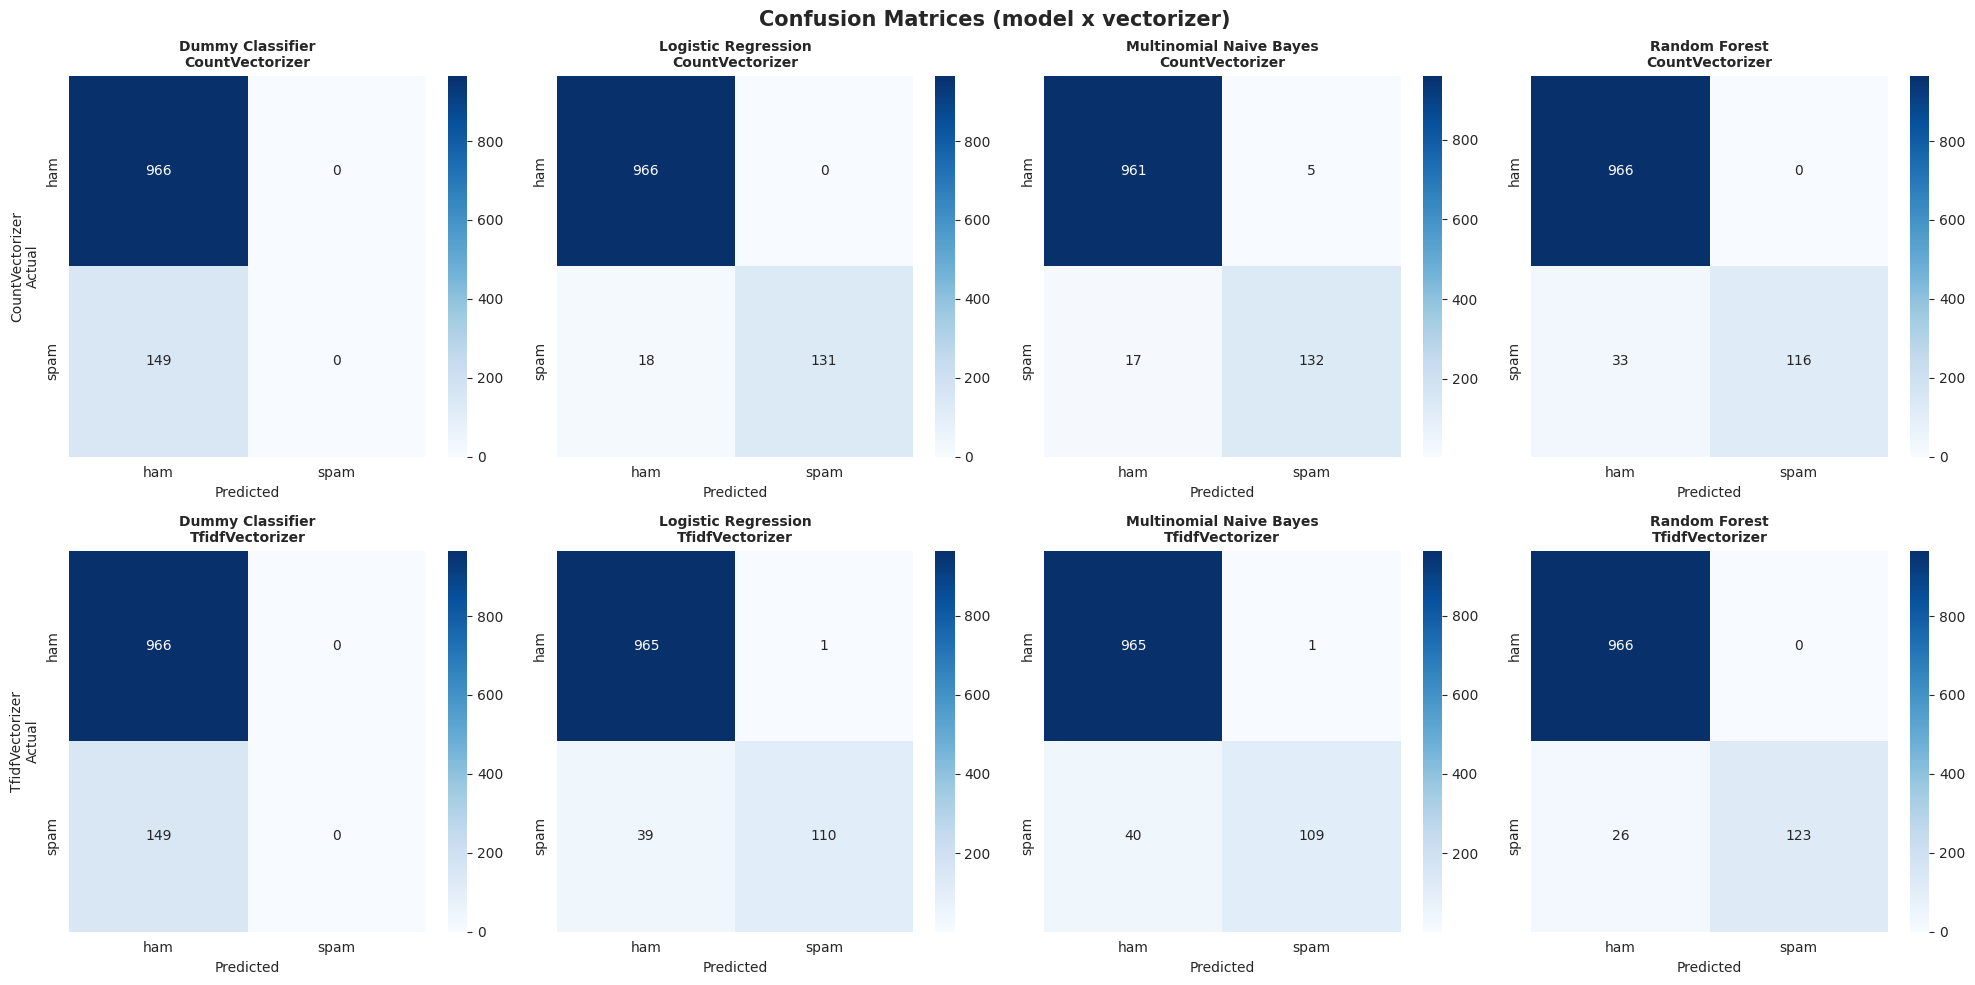

In [368]:
def build_pipelines(X_train, y_train):
    pipelines = {}
    for name, model in DEFAULT_MODELS.items():
        for vec_name, vectorizer_cls in VECTORIZERS.items():
            pipeline = build_pipeline(model, vectorizer_cls)
            pipeline.fit(X_train, y_train)
            pipelines[(name, vec_name)] = pipeline
    return pipelines


pipelines = build_pipelines(X_train, y_train)

fig, axes = plt.subplots(len(VECTORIZERS), len(DEFAULT_MODELS), figsize=(20, 10))

for model_idx, name in enumerate(DEFAULT_MODELS):
    for vec_idx, vec_name in enumerate(VECTORIZERS):
        ax = axes[vec_idx, model_idx]
        y_pred = pipelines[(name, vec_name)].predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
        ax.set_title(f'{name}\n{vec_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted')
        if model_idx == 0:
            ax.set_ylabel(f'{vec_name}\nActual')

plt.suptitle('Confusion Matrices (model x vectorizer)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

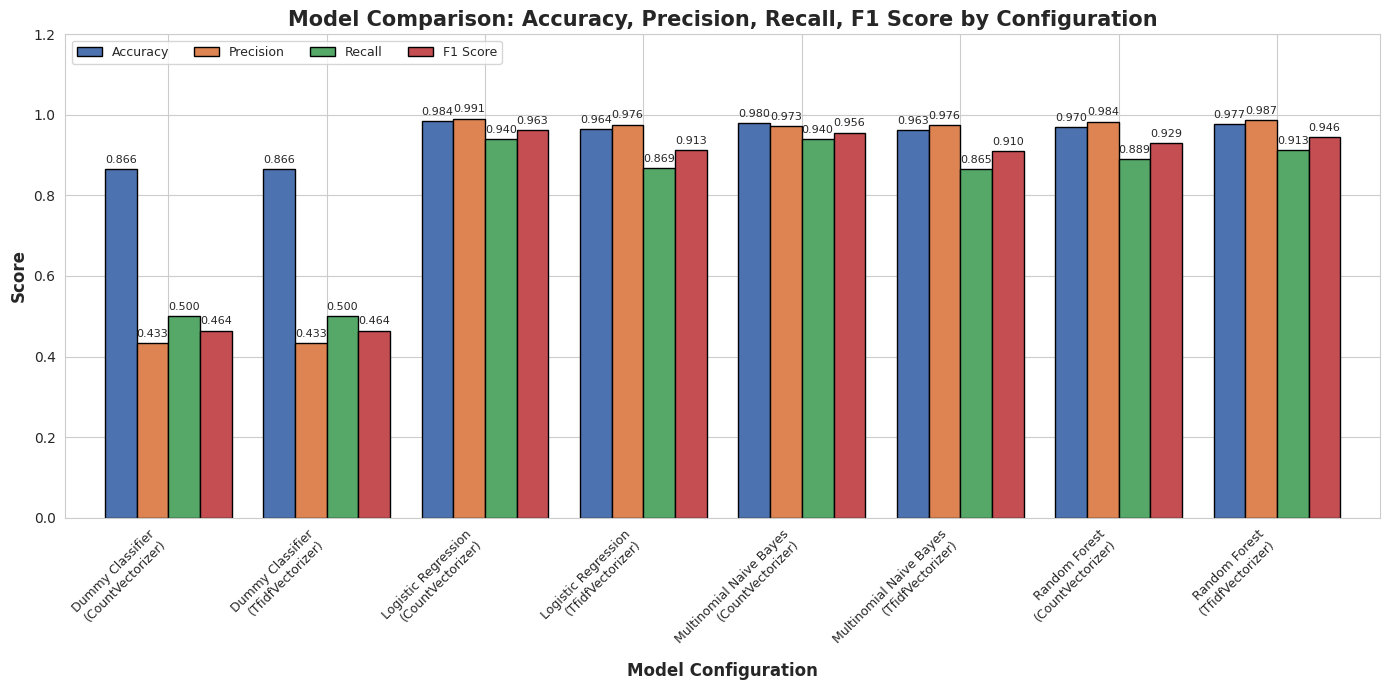


Best model by F1 Score: Logistic Regression using CountVectorizer (Score: 0.9632)


In [369]:
plot_df = results_df.copy()
plot_df['Label'] = plot_df['Model'] + '\n(' + plot_df['Vectorizer'] + ')'
plot_df = plot_df.set_index('Label')

f1_col = 'F1-Score' if 'F1-Score' in results_df.columns else 'F1 Score'

metric_cols = ['Accuracy', 'Precision', 'Recall', f1_col]
plot_data = plot_df[metric_cols]

ax = plot_data.plot(kind='bar', figsize=(14, 7), width=0.8,
                     color=metric_palette, edgecolor='black')
ax.set_ylim(0, 1.2)  
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Model Configuration', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison: Accuracy, Precision, Recall, F1 Score by Configuration',
             fontsize=15, fontweight='bold')
ax.legend(loc='upper left', ncol=4, fontsize=9)
ax.set_xticklabels(plot_data.index, rotation=45, ha='right', fontsize=9)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

if f1_col in results_df.columns:
    best_f1_idx = results_df[f1_col].idxmax()
    best_model_name = results_df.loc[best_f1_idx, 'Model']
    best_vec_name = results_df.loc[best_f1_idx, 'Vectorizer']
    print(f"\nBest model by F1 Score: {best_model_name} using {best_vec_name} (Score: {results_df.loc[best_f1_idx, f1_col]})")
else:
    print(f"\n'{f1_col}' column not found in results_df.")

### Precision vs. Recall Tradeoff

### Misclassified Examples

In [10]:
best = results_df.loc[results_df['Accuracy'].idxmax()]
print("Best configuration:", best['Model'], '+', best['Vectorizer'])

best_pipeline = build_pipeline(
    DEFAULT_MODELS[best['Model']],
    VECTORIZERS[best['Vectorizer']],
)
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

checks = pd.DataFrame({
    'text': df.loc[X_test.index, 'text'],
    'actual': y_test,
    'predicted': y_pred,
})
misclassified = checks[checks['actual'] != checks['predicted']]

false_spam = misclassified[misclassified['predicted'] == 'spam']
missed_spam = misclassified[misclassified['actual'] == 'spam']

print(f"Misclassified: {len(misclassified)} / {len(checks)} ({len(misclassified) / len(checks):.1%})")
print(f"  ham -> spam (false alarms): {len(false_spam)}")
print(f"  spam -> ham (missed spam):  {len(missed_spam)}")

print("\n--- Legitimate messages flagged as spam ---")
display(false_spam[['text']].head(5))

print("--- Spam that got through ---")
display(missed_spam[['text']].head(5))

Best configuration: Logistic Regression + CountVectorizer
              precision    recall  f1-score   support

         ham     0.9817    1.0000    0.9908       966
        spam     1.0000    0.8792    0.9357       149

    accuracy                         0.9839      1115
   macro avg     0.9909    0.9396    0.9632      1115
weighted avg     0.9842    0.9839    0.9834      1115

Misclassified: 18 / 1115 (1.6%)
  ham -> spam (false alarms): 0
  spam -> ham (missed spam):  18

--- Legitimate messages flagged as spam ---


,text


--- Spam that got through ---


,text
3057,You are now unsubscribed all services. Get ton...
5,FreeMsg Hey there darling it's been 3 week's n...
3979,ringtoneking 84484
3358,Sorry I missed your call let's talk when you h...
5449,"Latest News! Police station toilet stolen, cop..."


# 8. Conclusion

- **Winner: Logistic Regression + CountVectorizer (98.39%)** - highest accuracy of all configurations, and the best spam-catching profile: 99.1% precision, 94.0% recall (macro).
- **CountVectorizer beat TF-IDF in 2 of 3 models.** SMS spam is short and loaded with repeating keywords (*free*, *win*, *claim*), so raw counts already separate it well - a real insight, not an error.
- **TF-IDF's weakness is recall (86.5-86.9% vs 94.0% for Count)** - it misses more spam. In spam filtering a false negative is the costlier error, so this tips the tradeoff toward Count.
- **Dummy baseline: 86.6%** - it simply predicts "ham" every time, which confirms the class imbalance. Every real model beats it by ~12 points, and that gap is what makes the results meaningful.